# Koopman Operator Training with Autoencoder

This notebook implements a training pipeline for a Koopman operator model combined with an autoencoder. The code includes data loading, model definition, training, and visualization of results such as trajectories and eigenvalues.


In [1]:
import os
# Move up one directory to make sure the script can find the modules and save files in the correct place
os.chdir('..')
# Verify the current working directory
print(os.getcwd())

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn.init as init
import torch.multiprocessing as mp

# Import local modules (assuming these are available in your environment)
from utils.tools import set_seed, get_device
from utils.config_args import get_args
from utils.Viz import *
from KoopmanTrainer_AFT_DR import Trainer
from data_handler import KoopmanDataHandler
from models.autoencoder import AutoEncoder
from models.efficient_kan import *
from models.koopman_operator import Knet
from models.AFT import AttentionFreeTransformer

# Set multiprocessing start method
try:
    mp.set_start_method('spawn')
except RuntimeError:
    pass  # method already set

# Disable deterministic algorithms for flexibility
torch.use_deterministic_algorithms(False)


/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder


## Training Settings

Configure the training settings, including random seeds for reproducibility and device selection (CUDA or CPU).

In [2]:
# the version of pandas
def get_pandas_version():
    import numpy as np
    import pandas as pd
    return pd.__version__
print(f"Pandas version: {get_pandas_version()}")
import numpy as np
print(f"NumPy version: {np.__version__}")

Pandas version: 2.3.1
NumPy version: 2.0.1


In [3]:
# Get arguments (assuming get_args() handles command-line or default args)
args = get_args()

# Set seeds for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(args.seed)
torch.manual_seed(args.seed)
np.random.seed(args.seed)
set_seed(args.seed)

# Device configuration
device = get_device()

Using the CPU


In [4]:
# editing the args 
args.dataset = 'duffing_oscillator'
args.folder = 'simple_duffing_oscillator_AFT_DR'
args.time_steps = 201
args.prediction_length = 50
args.max_time = 10
args.num_samples = 6000
args.bottleneck = 100
args.decoder_loss_weight = .01
args.lr = 1e-3
args.epochs = 100
args.loss_function = 'mse'
args.unitary_loss_weight = 10
args.context_length = 10
args.load_from_checkpoint = True


## Create Experiment Folder

Set up the folder structure to save experiment results, including arguments in a JSON file.

In [5]:
# Create experiment folder
experiment_folder = 'experiments'
if not os.path.isdir(experiment_folder):
    os.mkdir(experiment_folder)

folder_path = os.path.join(experiment_folder, args.folder)
os.makedirs(folder_path, exist_ok=True)

# Save arguments to JSON
args_dict = vars(args)
with open(os.path.join(folder_path, 'args.json'), 'w') as f:
    json.dump(args_dict, f,indent=2)

## Load and Prepare Dataset

Load and preprocess the dataset using the `KoopmanDataHandler` class, then create data loaders for training, validation, and testing.

In [6]:
# Convert args to a dictionary for the data handler

config = {
    "dataset": args.dataset,
    "data_dir": args.data_dir,
    "train_size": args.train_size,
    "val_size": args.val_size,
    "batch_size": args.batch_size,
    "noise": args.noise,
    "orthogonal_projection": args.orthogonal_projection,
    "num_combinations": args.num_combinations,
    "num_samples": args.num_samples,
    "time_steps": args.time_steps,
    "max_time": args.max_time,
    "normalize": args.normalize,
    "prediction_length": args.prediction_length,
    "stride": args.stride,
    "device": device,
    "theta": args.theta
}

# Initialize data handler
data_handler = KoopmanDataHandler(config)
data_handler.load_data()
preprocessed_data = data_handler.preprocess()
dataloaders = data_handler.create_dataloaders()

train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

# Get data dimensions for model initialization
input_size = preprocessed_data['Xtrain'].shape[-1]

100%|██████████| 6000/6000 [00:00<00:00, 32746.25it/s]
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:178: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:179: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Xval = torch.tensor(Xval, dtype=torch.float32).to(self.device)
/Users/mohammedahmed/Desktop/Project/KoopKAN/Clean Code/bio-koopman-autoencoder/data_handler.py:180: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor

the shape of the data is torch.Size([6000, 201, 2])
Processing dataset: duffing_oscillator
train_idx: 4800, val_idx: 5400
Processed data shapes - Train: torch.Size([4800, 201, 2]), Val: torch.Size([600, 201, 2]), Test: torch.Size([600, 201, 2])


## Model Definition

Define the autoencoder (`AutoEncoder`) and Koopman operator (`Knet`), then combine them into a `ModuleDict`.

In [7]:
# Model definition
ae = AutoEncoder(
    input_size=input_size,
    encoded_size=args.bottleneck,
    encoder_hidden_layers=args.encoder_hidden_layers,
    decoder_hidden_layers=args.decoder_hidden_layers,
    network_type=args.network_type,
    batch_norm=False
)
knet = Knet(size=args.bottleneck)

AFT = AttentionFreeTransformer(d_model=args.bottleneck, max_seq_len=args.context_length, device=device)

# Combine AE and Knet as a ModuleDict
model = torch.nn.ModuleDict({'ae': ae, 'knet': knet,'aft_layer': AFT})
model = model.to(device)

## Model Summary

Display the total number of parameters and the model architecture.

In [8]:
print('**** Setup ****')
print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters())/1000000.0))
print('Total params: %.2fk' % (sum(p.numel() for p in model.parameters())/1000.0))
print('************')

print('**** Model Architecture ****')
print(model)
print('***************************')

**** Setup ****
Total params: 0.08M
Total params: 81.30k
************
**** Model Architecture ****
ModuleDict(
  (ae): AutoEncoder(
    (encoder): Sequential(
      (0): MLP(
        (net): ModuleList(
          (0): Linear(in_features=2, out_features=100, bias=True)
          (1): LeakyReLU(negative_slope=0.01)
          (2): Linear(in_features=100, out_features=100, bias=True)
          (3): LeakyReLU(negative_slope=0.01)
          (4): Linear(in_features=100, out_features=100, bias=True)
        )
      )
      (1): Dropout(p=0.3, inplace=False)
    )
    (decoder): MLP(
      (net): ModuleList(
        (0): Linear(in_features=100, out_features=100, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): Linear(in_features=100, out_features=100, bias=True)
        (3): LeakyReLU(negative_slope=0.01)
        (4): Linear(in_features=100, out_features=2, bias=True)
      )
    )
  )
  (knet): Knet(
    (net): Linear(in_features=100, out_features=100, bias=False)
  )
  (aft_

## Load from Checkpoint

Optionally load a pre-trained model from a checkpoint if specified.

In [9]:
if args.load_from_checkpoint:
    checkpoint_path = os.path.join(folder_path, 'model.pkl')
    if os.path.isfile(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path))
        print(f'Model loaded from {checkpoint_path}')
    else:
        print(f'No checkpoint found at {checkpoint_path}')

Model loaded from experiments/simple_duffing_oscillator_AFT_DR/model.pkl


/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_58353/546321609.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_pa


## Training

Train the model using the `Trainer` class with the specified data loaders.

In [10]:
trainer = Trainer(model, args, device, do_eval=True, train_loader=train_loader, val_loader=val_loader)

Using the CPU


In [11]:
trainer.train_KoopmanAE()

Training Epochs:   5%|▌         | 5/100 [05:59<1:53:17, 71.55s/it]

Epoch 5/100
Training - Recon Loss: 9.210581e-04, Linear Loss: 2.220491e-05, Pred Loss: 3.405183e-03, Unitary Loss: 7.815137e-07, Total Loss: 7.328247e-05
Validation - Recon Loss: 2.164668e-04, Linear Loss: 1.154717e-05, Pred Loss: 1.418665e-03,Unitary Loss: 5.267465e-07, Total Loss: 2.789850e-05


Training Epochs:  10%|█         | 10/100 [11:56<1:47:01, 71.35s/it]

Epoch 10/100
Training - Recon Loss: 6.521564e-04, Linear Loss: 1.419513e-05, Pred Loss: 1.891157e-03, Unitary Loss: 6.490632e-07, Total Loss: 4.611890e-05
Validation - Recon Loss: 1.268575e-04, Linear Loss: 7.505752e-06, Pred Loss: 2.101939e-03,Unitary Loss: 7.431318e-07, Total Loss: 2.979371e-05


Training Epochs:  15%|█▌        | 15/100 [17:40<1:37:32, 68.85s/it]

...

Training Epochs:  95%|█████████▌| 95/100 [1:50:17<05:38, 67.65s/it]

Epoch 95/100
Training - Recon Loss: 2.603152e-04, Linear Loss: 3.691760e-06, Pred Loss: 6.091172e-04, Unitary Loss: 5.070387e-07, Total Loss: 1.745647e-05
Validation - Recon Loss: 7.267276e-05, Linear Loss: 1.432189e-06, Pred Loss: 1.539661e-04,Unitary Loss: 4.746837e-07, Total Loss: 3.698577e-06


Training Epochs: 100%|██████████| 100/100 [1:56:06<00:00, 69.66s/it]

Epoch 100/100
Training - Recon Loss: 2.979059e-04, Linear Loss: 3.715287e-06, Pred Loss: 7.108669e-04, Unitary Loss: 5.581356e-07, Total Loss: 1.938437e-05
Validation - Recon Loss: 1.683574e-04, Linear Loss: 1.487257e-06, Pred Loss: 2.795082e-04,Unitary Loss: 4.619018e-07, Total Loss: 5.965912e-06


(ModuleDict(
   (ae): AutoEncoder(
     (encoder): Sequential(
       (0): MLP(
         (net): ModuleList(
           (0): Linear(in_features=2, out_features=100, bias=True)
           (1): LeakyReLU(negative_slope=0.01)
           (2): Linear(in_features=100, out_features=100, bias=True)
           (3): LeakyReLU(negative_slope=0.01)
           (4): Linear(in_features=100, out_features=100, bias=True)
         )
       )
       (1): Dropout(p=0.1, inplace=False)
     )
     (decoder): MLP(
       (net): ModuleList(
         (0): Linear(in_features=100, out_features=100, bias=True)
         (1): LeakyReLU(negative_slope=0.01)
         (2): Linear(in_features=100, out_features=100, bias=True)
         (3): LeakyReLU(negative_slope=0.01)
         (4): Linear(in_features=100, out_features=2, bias=True)
       )
     )
   )
   (knet): Knet(
     (net): Linear(in_features=100, out_features=100, bias=False)
   )
   (aft_layer): AttentionFreeTransformer(
     (Wq): Linear(in_features=100, ou

In [13]:
trainer.test_KoopmanAE(test_loader)

Test - Recon Loss: 1.704514e-04, Linear Loss: 1.443879e-06, Pred Loss: 2.721284e-04, Total Loss: 5.869677e-06


## Visualization

Visualize the original, reconstructed, and predicted trajectories from the test set.

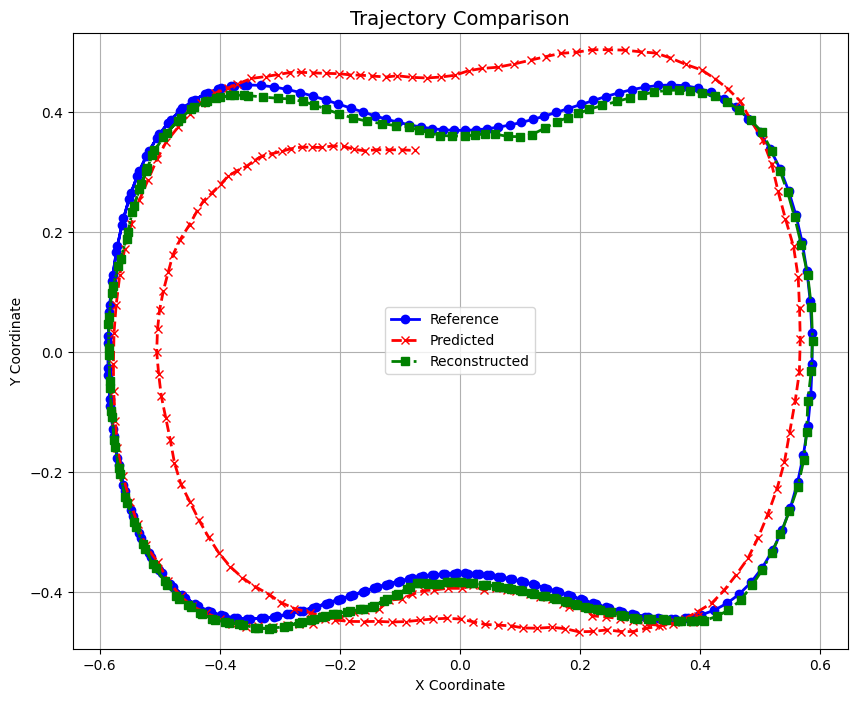

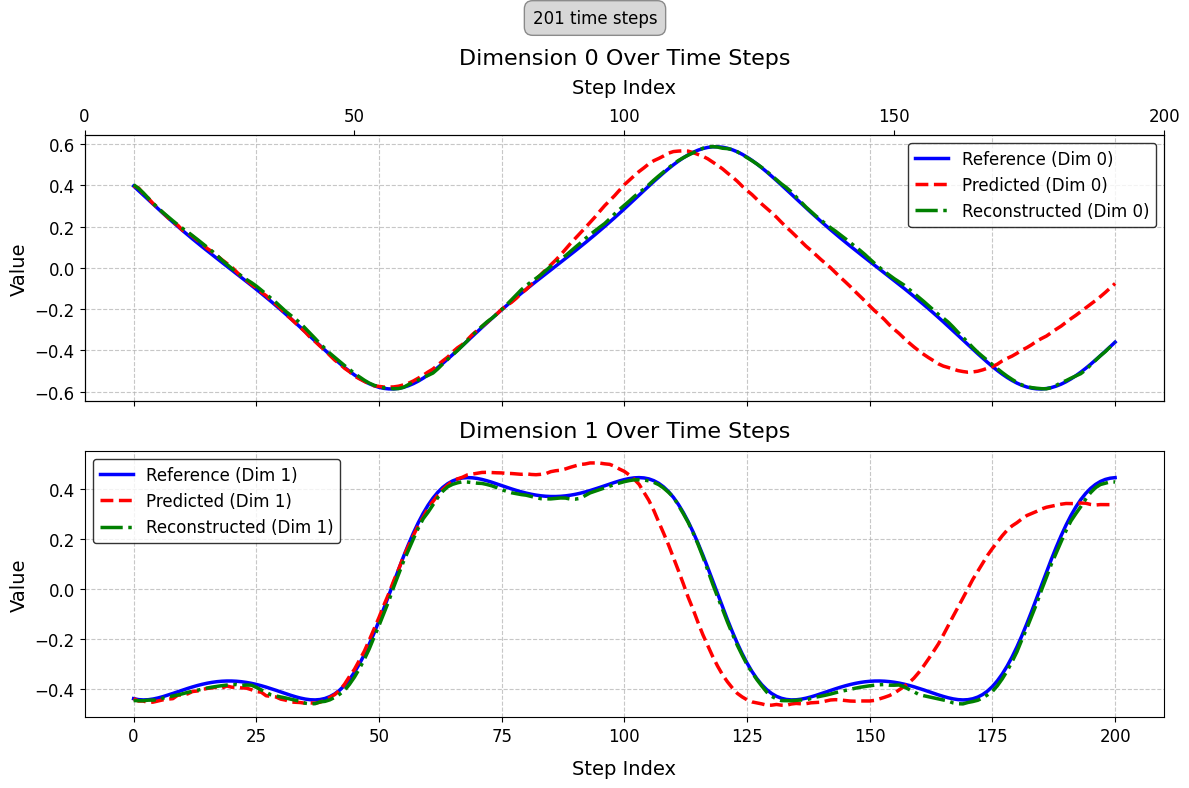

In [11]:
# for saving the results first

# Get a test sample
traj = preprocessed_data["Xtest"][3].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=True)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=True)

## Prediction without Reencoding

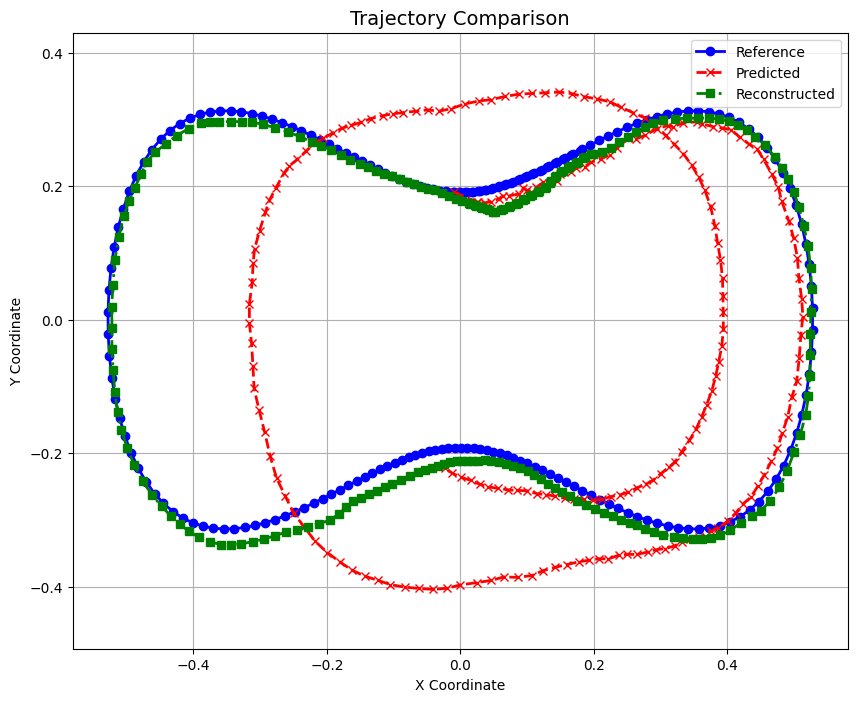

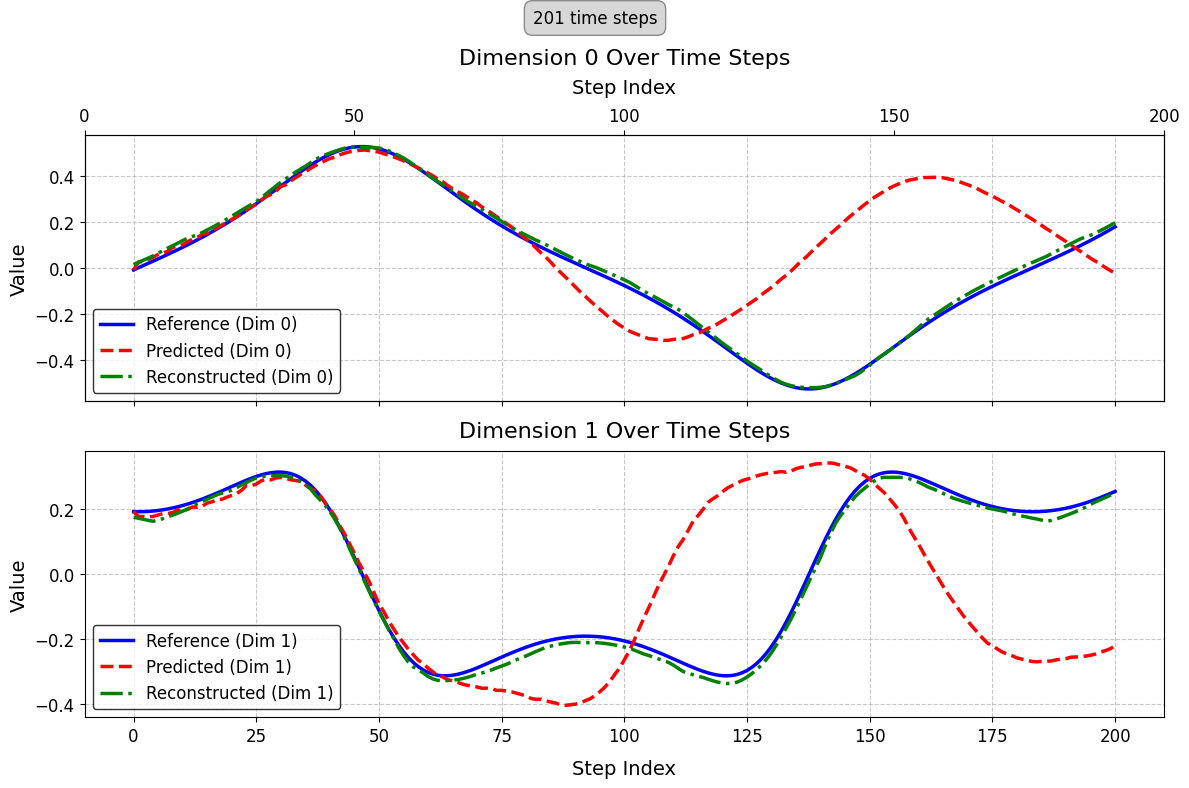

In [13]:
# Get a test sample
traj = preprocessed_data["Xtest"][11].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new(X0=traj[0], steps=len(traj)-1)


# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Prediction using Periodic Reencoding

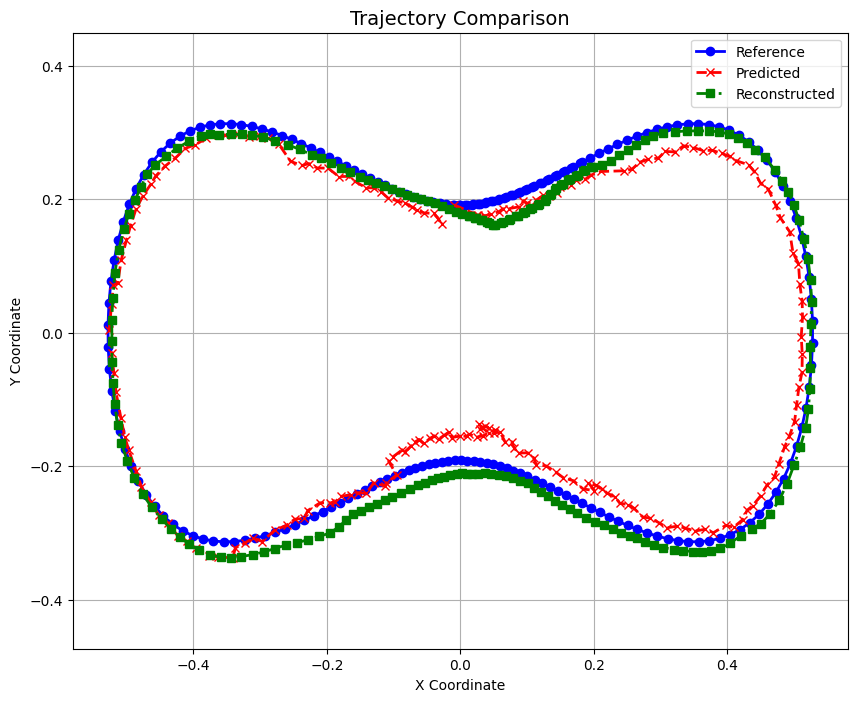

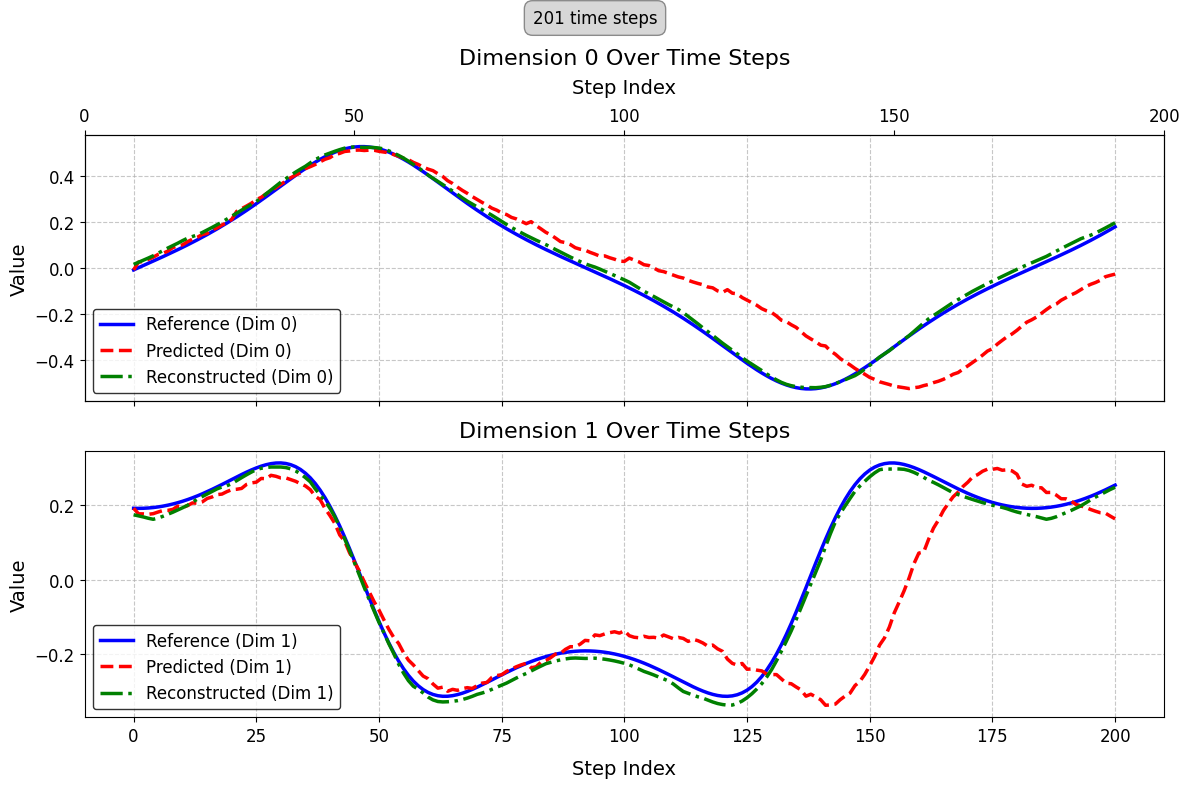

In [14]:
# Get a test sample
traj = preprocessed_data["Xtest"][11].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred = trainer.predict_new_Periodic_Reencoding(X0=traj[0],reenc=20, steps=len(traj)-1)


# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Prediction using specific Threshold

Reencoding points: [64, 81, 126, 167, 171, 172, 173, 174, 175, 176, 177, 178, 179]


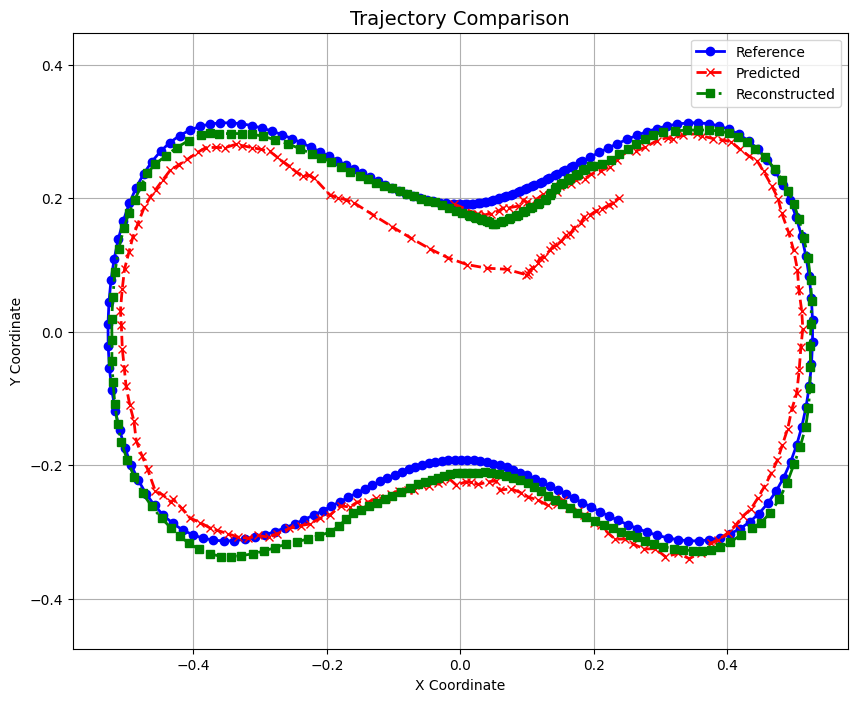

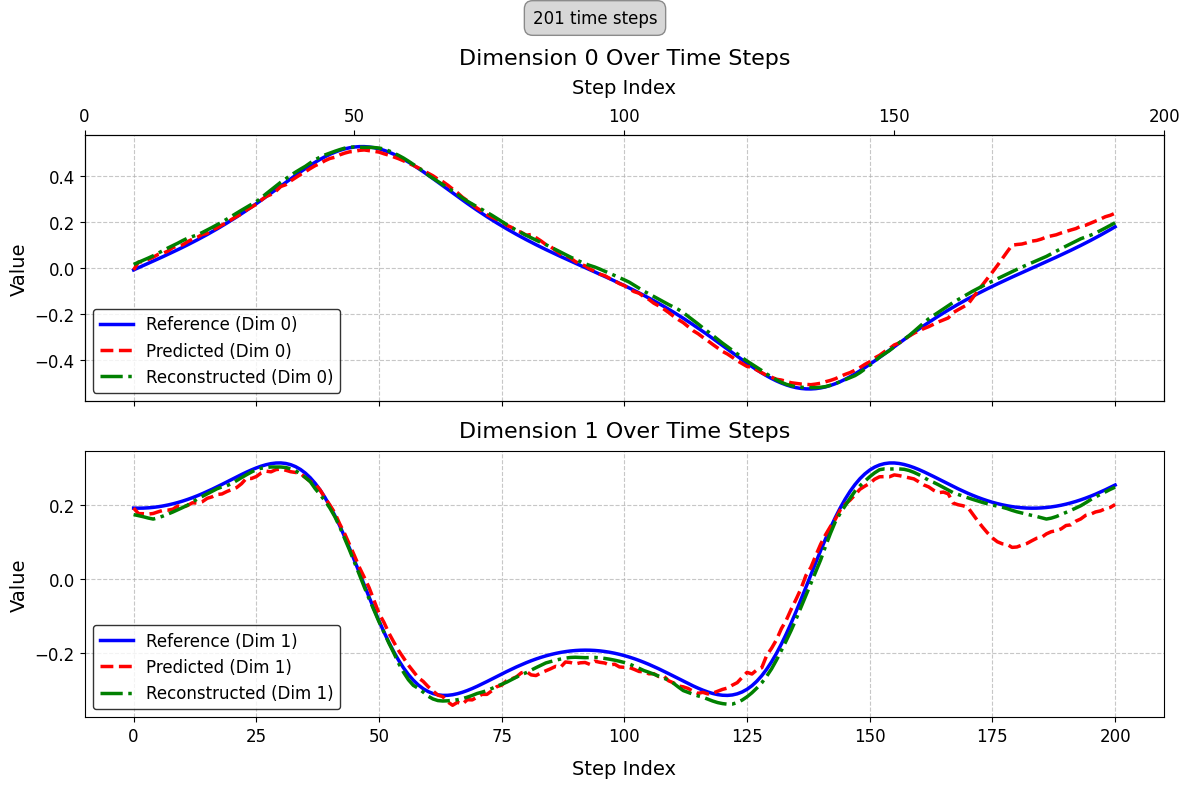

In [16]:
# Get a test sample
traj = preprocessed_data["Xtest"][11].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred, reenc_points = trainer.predict_with_threshold(X0=traj[0],threshold=0.5, steps=len(traj)-1)


print(f"Reencoding points: {reenc_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Reencoding Using Window Variance

Reencoding points: [34, 74, 84, 115, 151, 182, 184, 194]


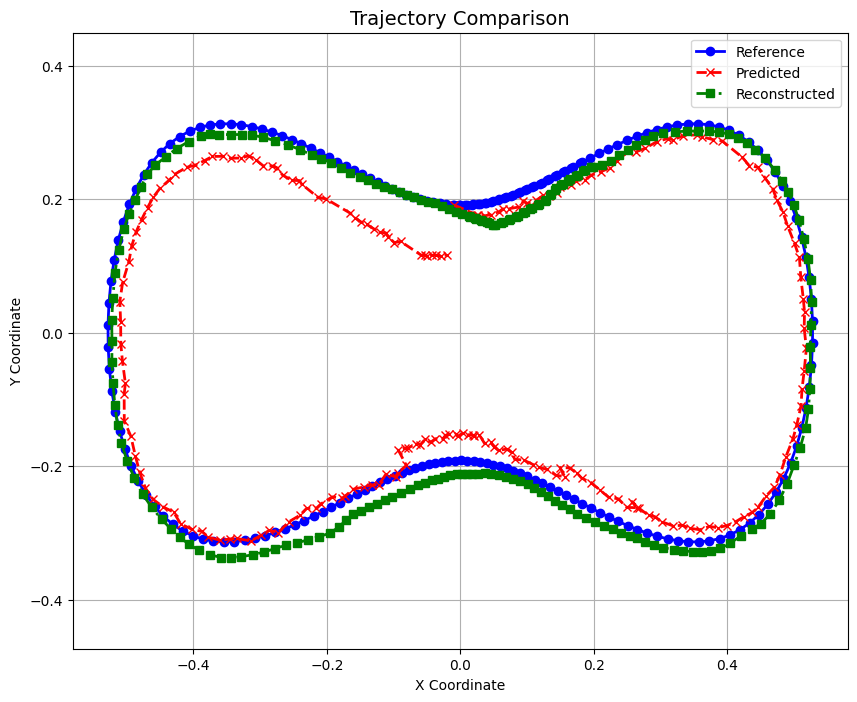

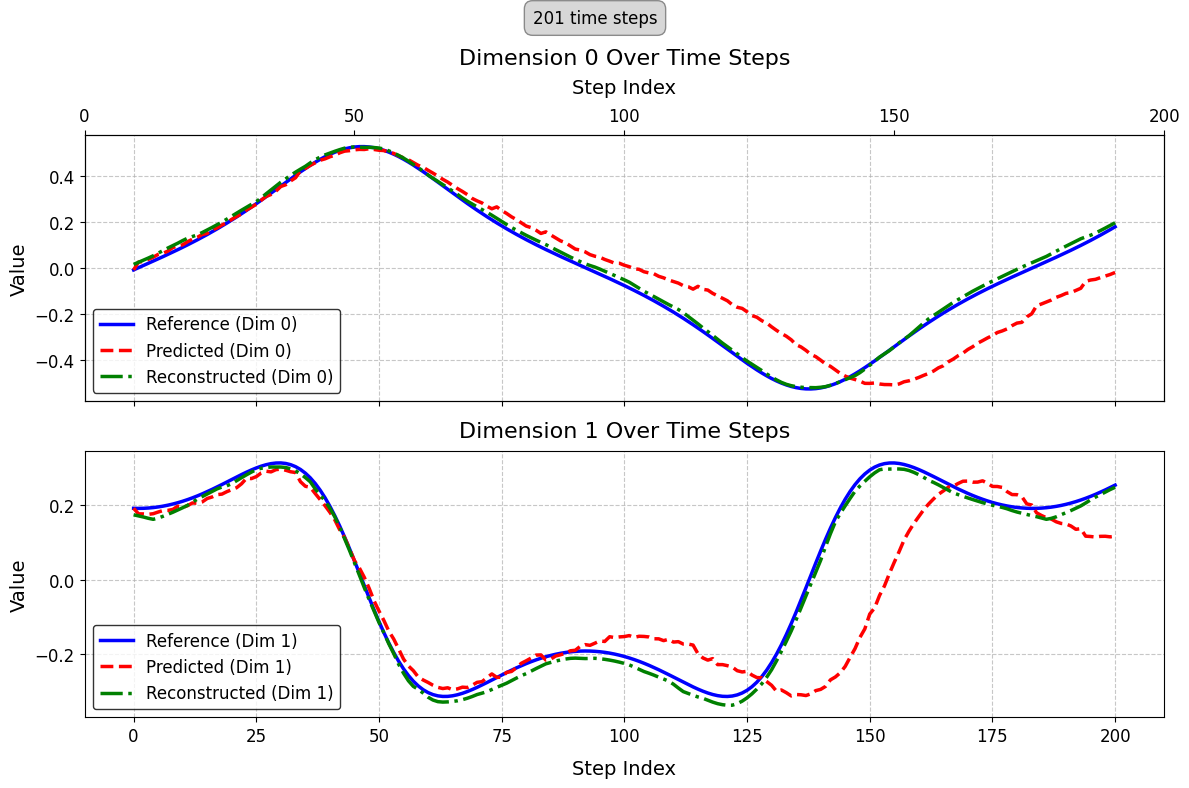

In [17]:
# Get a test sample
traj = preprocessed_data["Xtest"][11].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred, reenc_points, mse_history = trainer.predict_window_variance(X0=traj[0],window_size=10, variance_threshold=2, steps=len(traj)-1)


print(f"Reencoding points: {reenc_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Heuristic Methods

### Cummulative Sum CUMSUM

In [18]:
from typing import Tuple

class CusumMeanDetector():
        
    def __init__(self, t_warmup = 30, p_limit = 0.01) -> None:
        self._t_warmup = t_warmup
        self._p_limit = p_limit
        
        self._reset()
        
        

    def predict_next(self, y: torch.tensor) -> Tuple[float,bool]:
        self._update_data(y)

        if self.current_t == self._t_warmup:
            self._init_params()
        
        if self.current_t >= self._t_warmup:
            prob, is_changepoint = self._check_for_changepoint()
            if is_changepoint:
                self._reset()

            return (1-prob), is_changepoint
        
        else:
            return 0, False
            
    
    def _reset(self) -> None:
        self.current_t = torch.zeros(1)
                
        self.current_obs = []
        
        self.current_mean = None
        self.current_std = None
            
    
    def _update_data(self, y: torch.tensor) -> None:
        self.current_t += 1
        self.current_obs.append(y.reshape(1))

        
    
    def _init_params(self) -> None:
        self.current_mean = torch.mean(torch.concat(self.current_obs))
        self.current_std = torch.std(torch.concat(self.current_obs))
             
    
    def _check_for_changepoint(self) -> Tuple[float,bool]:
        standardized_sum = torch.sum(torch.concat(self.current_obs) - self.current_mean)/(self.current_std * self.current_t**0.5)
        prob = float(self._get_prob(standardized_sum).detach().numpy())
        
        return prob, prob < self._p_limit
    
    
    def _get_prob(self, y: torch.tensor) -> bool:
        p = torch.distributions.normal.Normal(0,1).cdf(torch.abs(y))
        prob = 2*(1 - p)
        
        return prob

In [19]:
def predict_with_cusum(self, X0, t_warmup=10, p_limit=0.01, steps=50) -> tuple:
    """
    Predict future states using AFT and Koopman operator with reencoding triggered by CUSUM change detection.
    """
    self.model.eval()
    with torch.no_grad():
        if not isinstance(X0, torch.Tensor):
            X0 = torch.tensor(X0, device=self.device)
        
        X0_batch = X0.unsqueeze(0) if X0.ndim == 1 else X0
        
        Xpred = torch.zeros((steps+1, *X0.shape), device=self.device)
        Xpred[0] = X0
        
        m = self.args.context_length  # Context window size
        reenc_points = []

        # Initialize CUSUM detector
        cusum = CusumMeanDetector(t_warmup=t_warmup, p_limit=p_limit)

        Y0 = self.model.ae.encoder(X0_batch)
        Y_history = [Y0.squeeze(0)]

        Y_next = self.model.knet(Y0)
        Xpred[1] = self.model.ae.decoder(Y_next).squeeze(0)
        Y_history.append(Y_next.squeeze(0))

        for t in range(2, steps+1):
            if t < m:
                context_list = Y_history[:t]
            else:
                context_list = Y_history[-m:]
            
            context = torch.stack(context_list).unsqueeze(0)
            aft_output = Y_history[-1] + self.model.aft_layer(context)
            Y_next = self.model.knet(aft_output)
            Y_next_before = Y_next

            # Predict and decode
            Xpred[t] = self.model.ae.decoder(Y_next).squeeze(0)

            # Reencoding check (CUSUM)
            Y_decoded = self.model.ae.decoder(Y_history[-1])
            Y_encoded = self.model.ae.encoder(Y_decoded)
            context[-1] = Y_encoded
            aft_output = Y_encoded + self.model.aft_layer(context)
            Y_next_after = self.model.knet(aft_output)

            # Metric: MSE difference (unnormalized or normalized)
            mse_diff = torch.mean((Y_next_after - Y_next_before) ** 2)

            # Feed MSE diff into CusumMeanDetector
            _, is_changepoint = cusum.predict_next(mse_diff)

            if is_changepoint:
                Y_history[-1] = Y_encoded
                Y_next = Y_next_after
                reenc_points.append(t)

            Xpred[t] = self.model.ae.decoder(Y_next).squeeze(0)
            Y_history.append(Y_next.squeeze(0))

    return Xpred, Y_history, reenc_points

Trainer.predict_with_cusum = predict_with_cusum

Reencoding points: [23, 36, 62, 80, 96, 115, 142, 167, 185, 198]


/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_58353/1392472785.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob = float(self._get_prob(standardized_sum).detach().numpy())


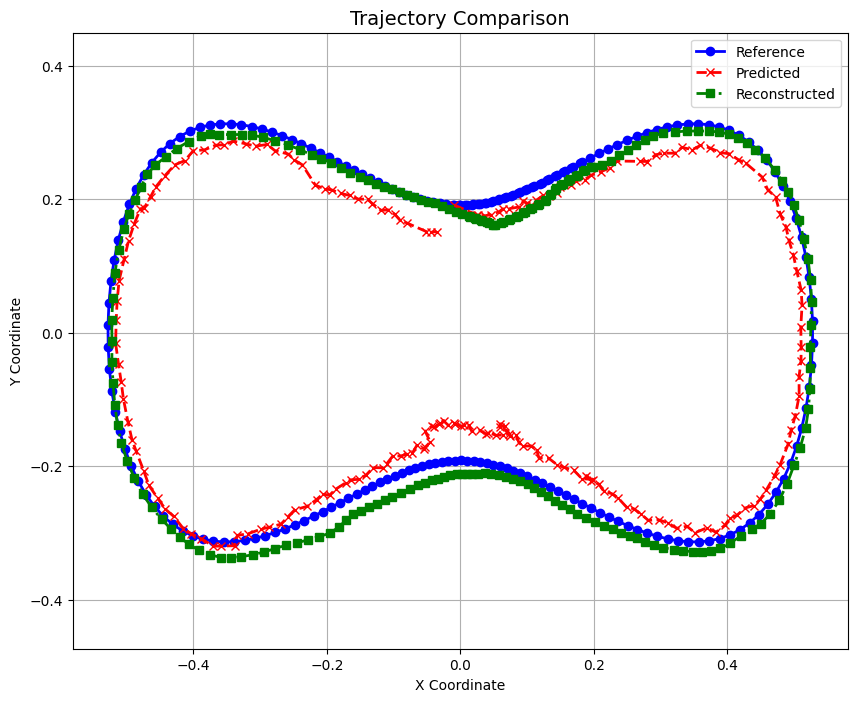

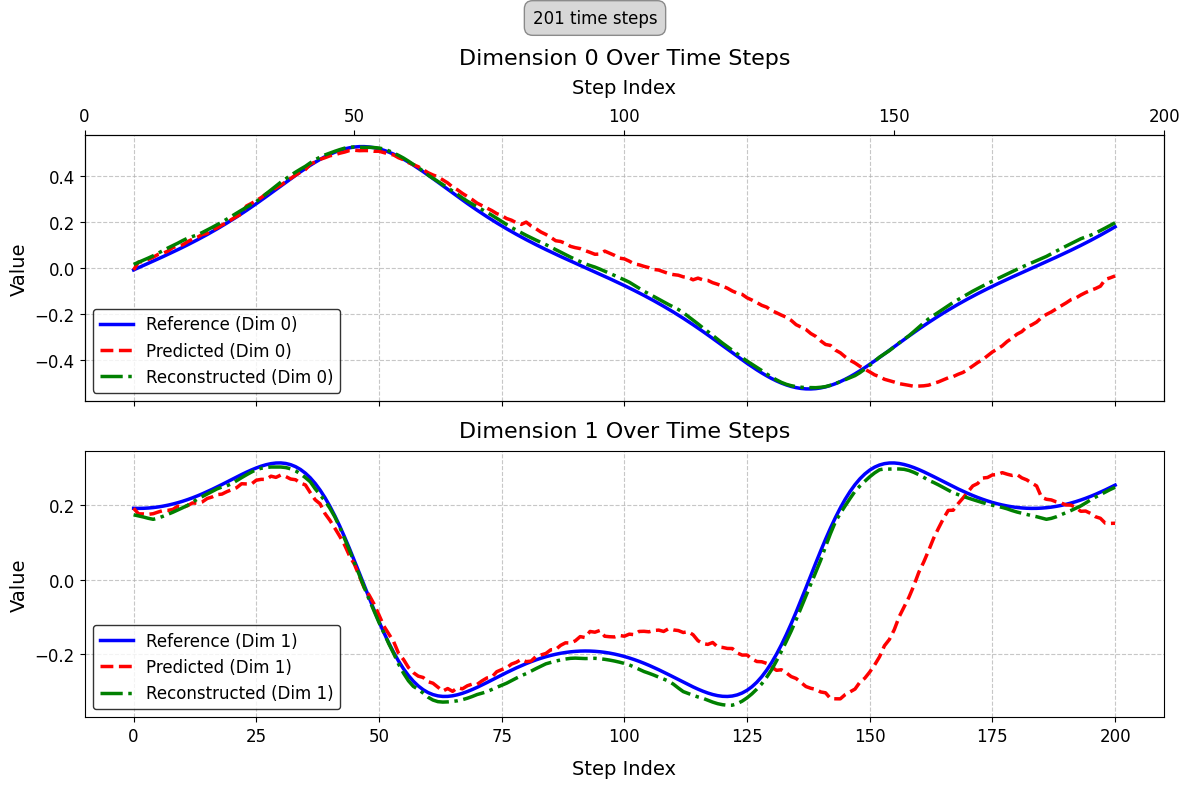

In [20]:
# Get a test sample
traj = preprocessed_data["Xtest"][11].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Get predicted trajectory
predicted_traj, latent_pred, reenc_points = trainer.predict_with_cusum(X0=traj[0], steps=len(traj)-1, t_warmup=10, p_limit=0.01)


print(f"Reencoding points: {reenc_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

### Expected Weighted Moving Average EWMA

In [21]:
class EWMA():
    """Exponentially Weighted Moving Average algorithm for online change detection."""

    def __init__(self, 
                 r: float = 0.1, 
                 L: float = 2.4, 
                 burnin: int = 50, 
                 mu: float = 0., 
                 sigma: float = 1.):
        self.r = r
        self.L = L
        self.burnin = burnin
        self.initial_mu = mu
        self.initial_sigma = sigma
        
        # Current estimates
        self.mu = mu
        self.sigma = sigma
        
        # History tracking
        self._mu = [mu]
        self._sigma = [sigma]
        self.Z = [mu]  # EWMA statistic
        self.sigma_Z = [0.]  # Standard deviation of Z
        self.changepoints = []
        
        # Counters
        self.t = 1  # Time index (starts from 1)
        self.n_since_last_change = 0  # Points since last change/start
        
        # State tracking
        self.in_burnin = True

    def update_mean_variance(self, data_new: float):
        """Update running mean and variance during burn-in or after reset."""
        if self.in_burnin or self.n_since_last_change < self.burnin:
            self.n_since_last_change += 1
            
            # Online mean and variance update
            if self.n_since_last_change == 1:
                self.mu = data_new
                self.sigma = 0.0
            else:
                old_mu = self.mu
                self.mu = old_mu + (data_new - old_mu) / self.n_since_last_change
                
                # Update variance using Welford's method
                if self.n_since_last_change > 1:
                    self.sigma = ((self.n_since_last_change - 2) * self.sigma**2 + 
                                (data_new - old_mu) * (data_new - self.mu)) / (self.n_since_last_change - 1)
                    self.sigma = max(self.sigma, 1e-8)**0.5  # Avoid division by zero
                else:
                    self.sigma = 1e-4  # Small default value
            
            self._mu.append(self.mu)
            self._sigma.append(self.sigma)
            
            # End burn-in period
            if self.n_since_last_change >= self.burnin:
                self.in_burnin = False

    def update_statistics(self, data_new: float):
        """Update EWMA statistic Z and its standard deviation."""
        # Update Z using EWMA formula
        z_new = (1 - self.r) * self.Z[-1] + self.r * data_new
        self.Z.append(z_new)
        
        # Update standard deviation of Z
        # Corrected formula for sigma_Z
        if self.t == 1:
            sigma_z_new = 0.0
        else:
            variance_factor = self.r / (2 - self.r)
            time_factor = 1 - (1 - self.r)**(2 * self.t)
            sigma_z_new = self.sigma * (variance_factor * time_factor)**0.5
        
        self.sigma_Z.append(sigma_z_new)

    def decision_rule(self) -> bool:
        """Apply decision rule to detect a change point."""
        # Only check for changes after burn-in period
        if not self.in_burnin and self.t > self.burnin and self.sigma_Z[-1] > 0:
            # Corrected decision rule: |Z - μ| > L * σ_Z
            control_limit = self.L * self.sigma_Z[-1]
            test_statistic = abs(self.Z[-1] - self.mu)
            
            if test_statistic > control_limit:
                self.changepoints.append(self.t)
                
                # Reset for next segment
                self.n_since_last_change = 0
                self.in_burnin = True  # Re-enter burn-in
                
                # Reset Z to current data point
                self.Z[-1] = self.Z[-1]  # Keep current Z value as starting point
                
                return True
        
        return False

    def process_one(self, data_point: float) -> bool:
        """
        Process a single data point and detect change if any.

        Parameters
        ----------
        data_point : float
            Incoming observation.

        Returns
        -------
        is_changepoint : bool
            True if a change point is detected, False otherwise.
        """
        # Update mean and variance (only during burn-in or after reset)
        self.update_mean_variance(data_point)
        
        # Update EWMA statistics
        self.update_statistics(data_point)
        
        # Apply decision rule
        is_changepoint = self.decision_rule()
        
        # Increment time counter
        self.t += 1
        
        return is_changepoint

    def get_current_state(self):
        """Get current state for debugging."""
        return {
            't': self.t,
            'mu': self.mu,
            'sigma': self.sigma,
            'Z': self.Z[-1] if self.Z else None,
            'sigma_Z': self.sigma_Z[-1] if self.sigma_Z else None,
            'in_burnin': self.in_burnin,
            'n_since_last_change': self.n_since_last_change,
            'changepoints': self.changepoints
        }

In [22]:
def predict_with_ewma(self, X0, steps=50, r=0.3, L=2.0, burnin=10) -> tuple:
    """
    Predict future states using AFT and Koopman operator with reencoding triggered by EWMA change detection.
    
    Args:
        X0: Initial condition
        steps: Number of prediction steps
        r: EWMA smoothing parameter (0.1-0.9)
        L: Control limit multiplier (1.0-3.0)
        burnin: Burn-in period for EWMA
    
    Returns:
        tuple: (Xpred, Ypred, reenc_points)
    """
    self.model.eval()
    with torch.no_grad():
        if not isinstance(X0, torch.Tensor):
            X0 = torch.tensor(X0, device=self.device)
        
        X0_batch = X0.unsqueeze(0) if X0.ndim == 1 else X0
        Xpred = torch.zeros((steps+1, *X0.shape), device=self.device)
        Xpred[0] = X0

        m = self.args.context_length
        reenc_points = []

        # Initialize EWMA detector
        ewma = EWMA(r=r, L=L, burnin=burnin)

        # Initial encoding
        Y0 = self.model.ae.encoder(X0_batch)
        Y_history = [Y0.squeeze(0)]

        # First prediction
        Y_next = self.model.knet(Y0)
        Xpred[1] = self.model.ae.decoder(Y_next).squeeze(0)
        Y_history.append(Y_next.squeeze(0))

        for t in range(2, steps+1):
            # Prepare context
            if t < m:
                context_list = Y_history[:t]
            else:
                context_list = Y_history[-m:]
            
            context = torch.stack(context_list).unsqueeze(0)
            
            # Current prediction path
            aft_output = Y_history[-1].unsqueeze(0) + self.model.aft_layer(context)
            Y_next_before = self.model.knet(aft_output)

            # Decode-encode cycle for reencoding check
            Y_current_batched = Y_history[-1].unsqueeze(0)
            Y_decoded = self.model.ae.decoder(Y_current_batched)
            Y_encoded = self.model.ae.encoder(Y_decoded)
            
            # Alternative prediction path with reencoding
            context_reenc = context.clone()
            context_reenc[0, -1] = Y_encoded.squeeze(0)
            aft_output_reenc = Y_encoded.squeeze(0).unsqueeze(0) + self.model.aft_layer(context_reenc)
            Y_next_after = self.model.knet(aft_output_reenc)

            # Calculate difference and check for change
            mse_diff = torch.mean((Y_next_after - Y_next_before) ** 2)
            mse_diff_scaled = mse_diff * 1e6  # Scale for EWMA
            is_changepoint = ewma.process_one(float(mse_diff_scaled))

            # Choose prediction path
            if is_changepoint:
                Y_history[-1] = Y_encoded.squeeze(0)
                Y_next = Y_next_after
                reenc_points.append(t)
            else:
                Y_next = Y_next_before

            # Store prediction and update history
            Xpred[t] = self.model.ae.decoder(Y_next).squeeze(0)
            Y_history.append(Y_next.squeeze(0))

    return Xpred, Y_history, reenc_points

# Attach to trainer
Trainer.predict_with_ewma = predict_with_ewma

Reencoding points: [32, 72, 92, 112, 152, 188]


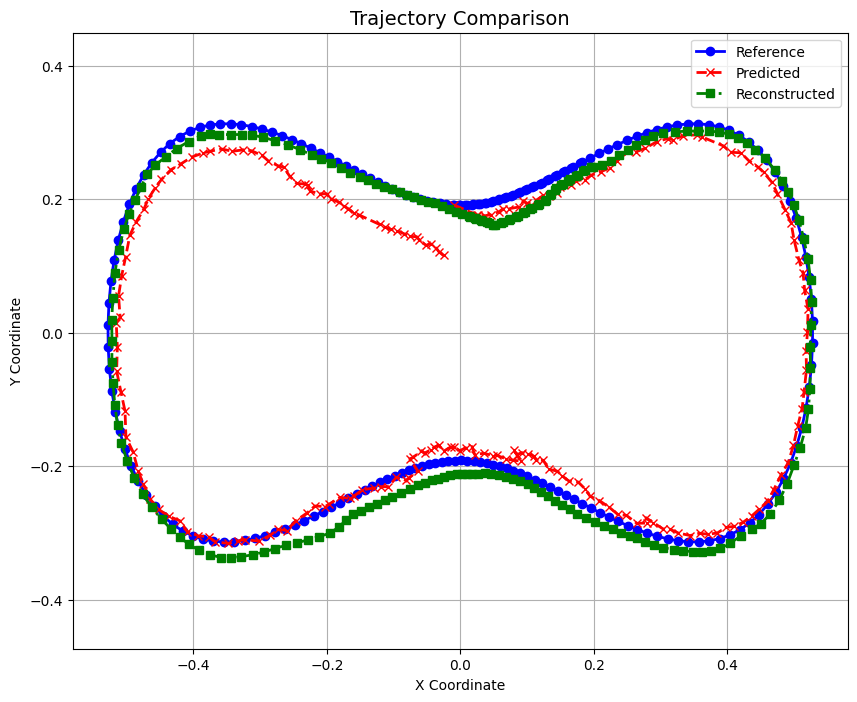

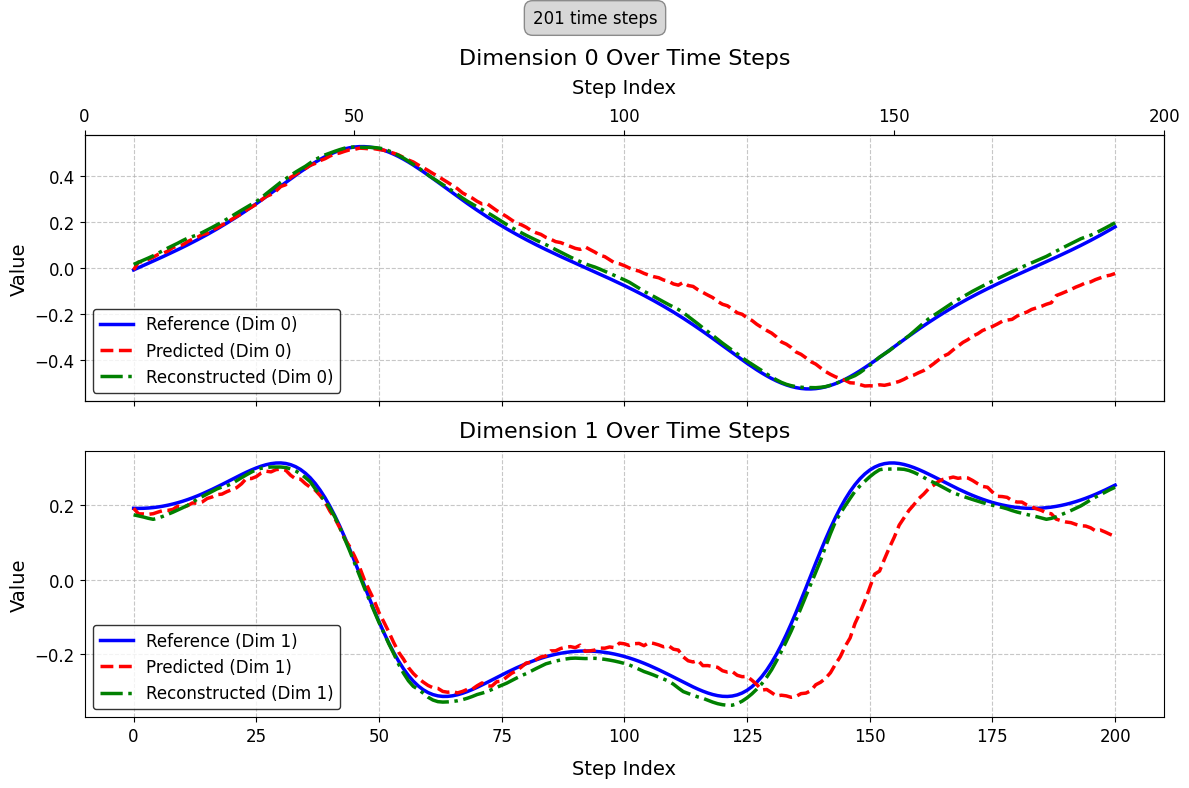

In [23]:
# Get a test sample
traj = preprocessed_data["Xtest"][11].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)


# Simple usage
predicted_traj, latent_pred, reenc_points = trainer.predict_with_ewma(
    X0=traj[0], 
    steps=len(traj)-1, 
    r=0.5,      # Responsiveness
    L=2.5,      # Threshold
    burnin=20   # Burn-in period
)

print(f"Reencoding points: {reenc_points}")

# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

### Two Samples detection

In [24]:
from collections import deque
from scipy.stats import ranksums, mood, mannwhitneyu, ks_2samp, cramervonmises_2samp

class TwoSample():
    """Online two-sample test for change detection with rolling windows."""

    def __init__(self, 
                 statistic: str = "Lepage", 
                 threshold: float = 3.1, 
                 window_size: int = 20):
        self.threshold = threshold
        self.stat_name = statistic
        self.window_size = window_size
        self.changepoints = []
        self.t = 0  # Time index

        # Rolling buffers
        self.window_past = deque(maxlen=window_size)
        self.window_recent = deque(maxlen=window_size)

        self._fetch_statistic()

    def _fetch_statistic(self):
        db = {
            "Mann-Whitney": mannwhitneyu,
            "Mood": mood,
            "Lepage": ranksums,
            "Kolmogorov-Smirnov": ks_2samp,
            "Cramer-von-Mises": cramervonmises_2samp
        }
        self.statistic = db[self.stat_name]

    def _compute_statistic(self, x, y):
        try:
            return abs(self.statistic(x, y)[0])
        except:
            try:
                return abs(self.statistic(x, y).statistic)
            except:
                return 0.0

    def process_one(self, data_point: float) -> bool:
        """
        Process a single data point and check for a change point.
        
        Parameters
        ----------
        data_point : float
            New observation.

        Returns
        -------
        is_changepoint : bool
            True if a change point is detected, False otherwise.
        """
        self.t += 1

        # Fill past window first
        if len(self.window_past) < self.window_size:
            self.window_past.append(data_point)
            return False

        # Fill recent window second
        if len(self.window_recent) < self.window_size:
            self.window_recent.append(data_point)
            return False

        # Now we have both windows full, compute test statistic
        x = list(self.window_past)
        y = list(self.window_recent)
        stat = self._compute_statistic(x, y)

        if stat > self.threshold:
            self.changepoints.append(self.t)
            # Reset windows after change
            self.window_past.clear()
            self.window_recent.clear()
            self.window_past.append(data_point)
            return True

        # Slide windows
        self.window_past.append(self.window_recent.popleft())
        self.window_recent.append(data_point)

        return False


In [25]:
def predict_with_twosample(self, X0, threshold=3.1, window_size=20, statistic="Lepage", steps=50) -> tuple:
    """
    Predict future states using AFT and Koopman operator with reencoding triggered by two-sample tests.
    """
    self.model.eval()
    with torch.no_grad():
        if not isinstance(X0, torch.Tensor):
            X0 = torch.tensor(X0, device=self.device)
        
        X0_batch = X0.unsqueeze(0) if X0.ndim == 1 else X0
        Xpred = torch.zeros((steps+1, *X0.shape), device=self.device)
        Xpred[0] = X0

        m = self.args.context_length
        reenc_points = []

        detector = TwoSample(statistic=statistic, threshold=threshold, window_size=window_size)

        Y0 = self.model.ae.encoder(X0_batch)
        Y_history = [Y0.squeeze(0)]

        Y_next = self.model.knet(Y0)
        Xpred[1] = self.model.ae.decoder(Y_next).squeeze(0)
        Y_history.append(Y_next.squeeze(0))

        for t in range(2, steps+1):
            context = torch.stack(Y_history[-m:] if t >= m else Y_history[:t]).unsqueeze(0)
            aft_output = Y_history[-1] + self.model.aft_layer(context)
            Y_next = self.model.knet(aft_output)
            Y_next_before = Y_next

            # Decode and re-encode to check consistency
            Y_decoded = self.model.ae.decoder(Y_history[-1])
            Y_encoded = self.model.ae.encoder(Y_decoded)
            context[-1] = Y_encoded
            aft_output = Y_encoded + self.model.aft_layer(context)
            Y_next_after = self.model.knet(aft_output)

            mse_diff = torch.mean((Y_next_after - Y_next_before) ** 2)
            is_changepoint = detector.process_one(float(mse_diff))

            if is_changepoint:
                Y_history[-1] = Y_encoded
                Y_next = Y_next_after
                reenc_points.append(t)

            Xpred[t] = self.model.ae.decoder(Y_next).squeeze(0)
            Y_history.append(Y_next.squeeze(0))

    return Xpred, Y_history, reenc_points

Trainer.predict_with_twosample = predict_with_twosample

Reencoding points: [22, 42, 62, 83, 103, 124, 144, 169, 189]


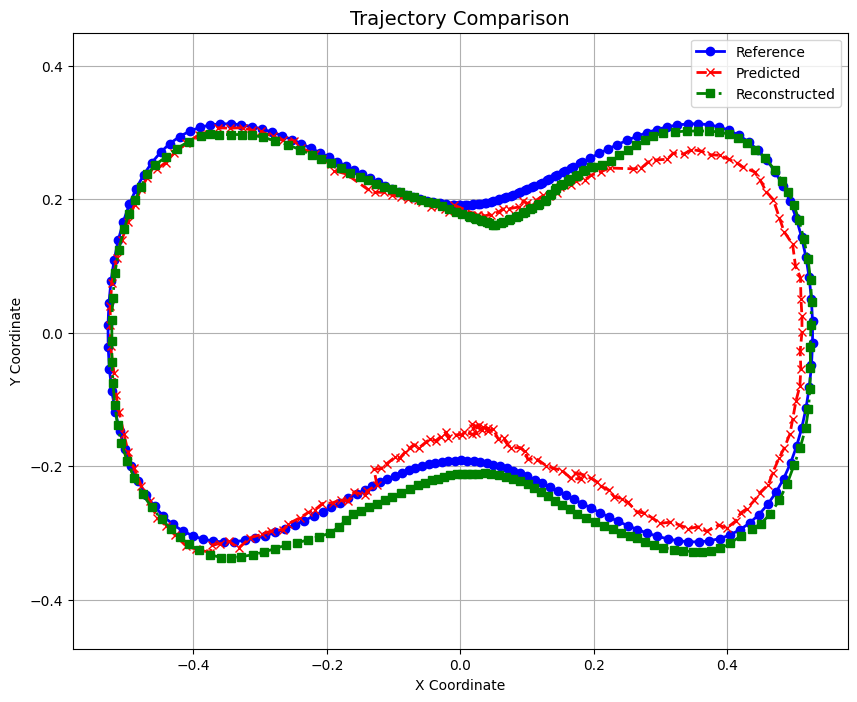

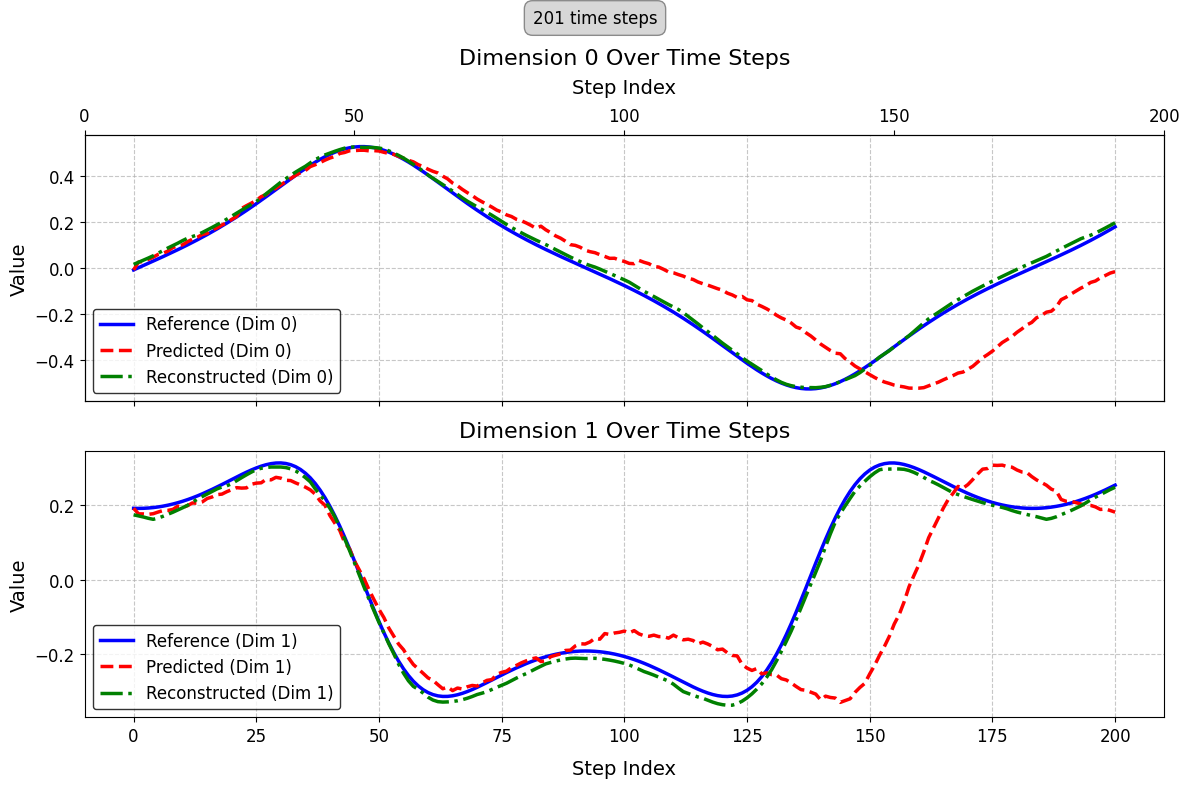

In [27]:
# Get a test sample
traj = preprocessed_data["Xtest"][11].to(device)

# Get reconstructed trajectory
model.eval()
with torch.no_grad():
    Y, reconstructed_traj = model.ae(traj)

'''
            "Mann-Whitney": mannwhitneyu,
            "Mood": mood,
            "Lepage": ranksums,
            "Kolmogorov-Smirnov": ks_2samp,
            "Cramer-von-Mises": cramervonmises_2samp
'''

# Get predicted trajectory
predicted_traj, latent_pred, reenc_points = trainer.predict_with_twosample(X0=traj[0], steps=len(traj)-1, threshold=2, window_size=10)

print(f"Reencoding points: {reenc_points}")
# Convert to numpy for plotting
traj = traj.cpu().detach().numpy()
reconstructed_traj = reconstructed_traj.cpu().detach().numpy()
predicted_traj = predicted_traj.cpu().detach().numpy()

# Plot trajectories
plot_trajectories(traj[:,:3], predicted_traj[:,:3], reconstructed_traj[:,:3], folder_path=folder_path,save=False)
plot_trajectory_comparison(traj, predicted_traj, reconstructed_traj, folder_path=folder_path,save=False)

## Testing Inference Models

Evaluating method: predict_AFT
Evaluating method: predict_periodic_Reencoding
Evaluating method: predict_threshold_Reencoding
Evaluating method: predict_window_variance_Reencoding
Evaluating method: predict_with_cusum


/var/folders/5_/hq2ly88s2fxbtph44558kg8m0000gn/T/ipykernel_58353/1392472785.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob = float(self._get_prob(standardized_sum).detach().numpy())


Evaluating method: TwoSample
Evaluating method: EWMA

Evaluation Results with Confidence Intervals:
Average cumulative MAE over trajectory:
--------------------------------------------------
predict_AFT: 7.4059
predict_periodic_Reencoding: 4.1909
predict_threshold_Reencoding: 5.5668
predict_window_variance_Reencoding: 4.3460
predict_with_cusum: 3.9733
TwoSample: 3.4120
EWMA: 3.9152

Overall MSE per trajectory (like original code):
--------------------------------------------------
predict_AFT: 0.0427
predict_periodic_Reencoding: 0.0156
predict_threshold_Reencoding: 0.0290
predict_window_variance_Reencoding: 0.0186
predict_with_cusum: 0.0151
TwoSample: 0.0113
EWMA: 0.0144

Time-step analysis:
--------------------------------------------------
predict_AFT:
  Final step MSE: 25.9643
  95% CI: [25.1375, 26.7911]
  Trajectories: 600

predict_periodic_Reencoding:
  Final step MSE: 13.7301
  95% CI: [13.0203, 14.4400]
  Trajectories: 600

predict_threshold_Reencoding:
  Final step MSE: 18.916

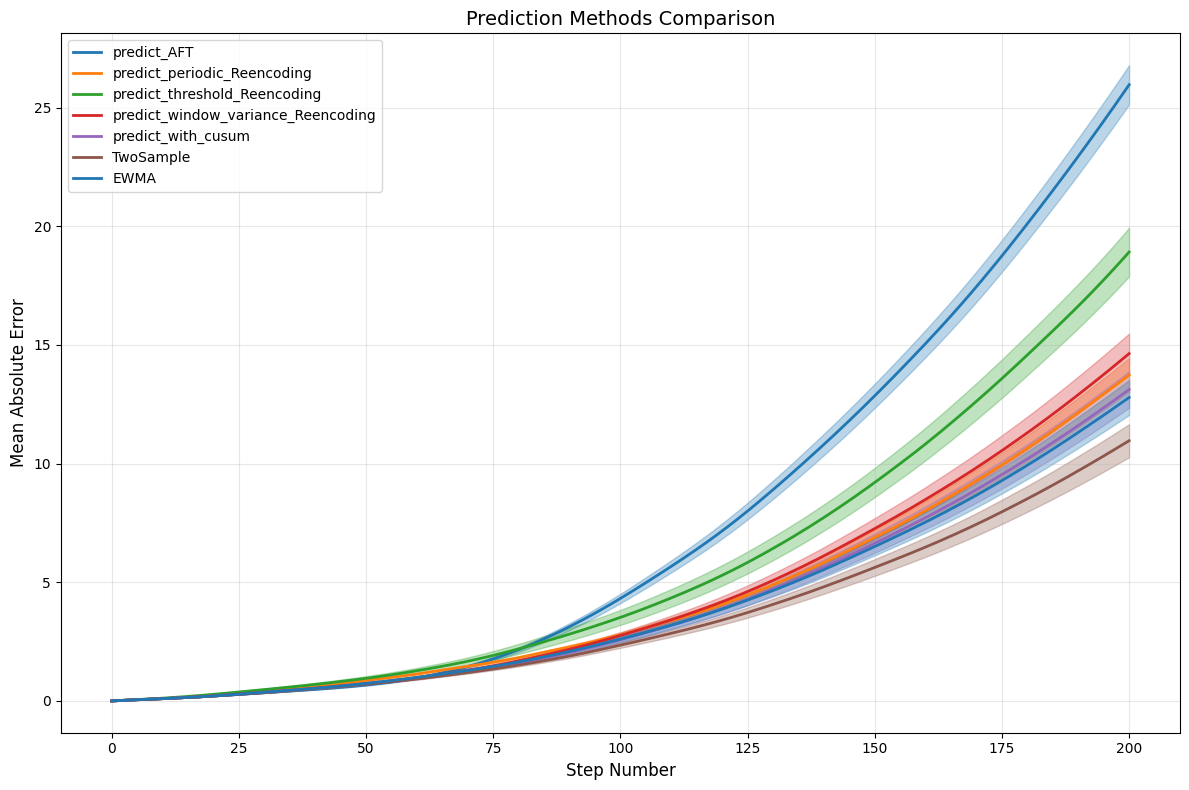

In [28]:
from scipy import stats

def evaluate_all_methods_with_confidence(preprocessed_data, model, trainer, device, confidence_level=0.95):
    model.eval()
    Xtest = preprocessed_data["Xtest"]
    
    # Define the inference methods
    def ae_reconstruction(traj):
        with torch.no_grad():
            _, reconstructed = model.ae(traj)
        return reconstructed
    
    def predict_cumsum(traj):
        return trainer.predict_with_cusum(X0=traj[0], t_warmup=20, p_limit=0.01, steps=len(traj) - 1)[0]
    
    def TwoSample(traj):
        return trainer.predict_with_twosample(X0=traj[0], threshold=2, window_size=15, steps=len(traj) - 1)[0]
    
    def predict_EWMA(traj):
        return trainer.predict_with_ewma(X0=traj[0], steps=len(traj) - 1, r=0.5, L=2.5, burnin=20)[0]

    def predict_new(traj):
        return trainer.predict_new(X0=traj[0], steps=len(traj) - 1)[0]

    def predict_new_periodic(traj):
        return trainer.predict_new_Periodic_Reencoding(X0=traj[0], reenc=20, steps=len(traj) - 1)[0]

    def predict_with_threshold(traj):
        return trainer.predict_with_threshold(X0=traj[0], threshold=0.5, steps=len(traj) - 1)[0]

    def predict_window_variance(traj):
        return trainer.predict_window_variance(X0=traj[0], window_size=10, variance_threshold=2, steps=len(traj) - 1)[0]

    methods = {
        "predict_AFT": predict_new,
        "predict_periodic_Reencoding": predict_new_periodic,
        "predict_threshold_Reencoding": predict_with_threshold,
        "predict_window_variance_Reencoding": predict_window_variance,
        "predict_with_cusum" : predict_cumsum,
        "TwoSample" : TwoSample,
        "EWMA": predict_EWMA
    }

    # Store results for each method
    method_results = {}
    
    for name, func in methods.items():
        print(f"Evaluating method: {name}")
        
        # Store squared errors for each time step across all trajectories
        all_squared_errors = []
        all_trajectory_mses = []  # Store overall MSE per trajectory (like original code)
        max_steps = 0
        
        for traj in Xtest:
            traj = traj.to(device)
            try:
                predicted_traj = func(traj)
                
                # Calculate absolute error at each time step
                step_errors = torch.mean(torch.abs(predicted_traj - traj), dim=-1)  # Average over features
                
                # Calculate cumulative error
                squared_errors = torch.cumsum(step_errors, dim=0).cpu().numpy()
                
                # Calculate overall MSE for this trajectory (like original code) 
                trajectory_mse = torch.mean((predicted_traj - traj) ** 2).item()
                
                all_squared_errors.append(squared_errors)
                all_trajectory_mses.append(trajectory_mse)
                max_steps = max(max_steps, len(squared_errors))
                
            except Exception as e:
                print(f"Error with trajectory in {name}: {e}")
                continue
        
        if not all_squared_errors:
            print(f"No valid results for {name}")
            continue
            
        # Pad shorter sequences with NaN
        padded_errors = []
        for errors in all_squared_errors:
            padded = np.full(max_steps, np.nan)
            padded[:len(errors)] = errors
            padded_errors.append(padded)
        
        padded_errors = np.array(padded_errors)
        
        # Calculate statistics at each time step
        mean_errors = np.nanmean(padded_errors, axis=0)
        std_errors = np.nanstd(padded_errors, axis=0)
        n_valid = np.sum(~np.isnan(padded_errors), axis=0)
        
        # Calculate confidence intervals
        alpha = 1 - confidence_level
        confidence_intervals = []
        
        for i in range(max_steps):
            valid_errors = padded_errors[:, i]
            valid_errors = valid_errors[~np.isnan(valid_errors)]
            
            if len(valid_errors) > 1:
                # Use t-distribution for confidence intervals
                t_stat = stats.t.ppf(1 - alpha/2, len(valid_errors) - 1)
                margin_error = t_stat * std_errors[i] / np.sqrt(len(valid_errors))
                ci_lower = mean_errors[i] - margin_error
                ci_upper = mean_errors[i] + margin_error
            else:
                ci_lower = ci_upper = mean_errors[i]
            
            confidence_intervals.append((ci_lower, ci_upper))
        
        confidence_intervals = np.array(confidence_intervals)
        
        method_results[name] = {
            'mean_errors': mean_errors,
            'std_errors': std_errors,
            'confidence_intervals': confidence_intervals,
            'n_trajectories': len(all_squared_errors),
            'steps': np.arange(max_steps),
            'overall_mse': np.mean(all_trajectory_mses)  # Overall MSE like original code
        }
    
    return method_results

def plot_results_with_confidence(results, title="Prediction Error Over Time", figsize=(12, 8)):
    """
    Plot results similar to the DuffingOscillator screenshot
    """
    plt.figure(figsize=figsize)
    
    # Color palette similar to the screenshot
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, (method_name, data) in enumerate(results.items()):
        color = colors[i % len(colors)]
        steps = data['steps']
        mean_errors = data['mean_errors']
        ci_lower = data['confidence_intervals'][:, 0]
        ci_upper = data['confidence_intervals'][:, 1]
        
        # Plot mean line
        plt.plot(steps, mean_errors, color=color, linewidth=2, label=method_name)
        
        # Plot confidence interval as shaded area
        plt.fill_between(steps, ci_lower, ci_upper, color=color, alpha=0.3)
    
    plt.xlabel('Step Number', fontsize=12)
    plt.ylabel('Mean Absolute Error', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return plt.gcf()

# Usage example:
def run_enhanced_evaluation(preprocessed_data, model, trainer, device):
    # Run evaluation with confidence intervals
    results = evaluate_all_methods_with_confidence(
        preprocessed_data, model, trainer, device, confidence_level=0.95
    )
    
    # Print summary statistics
    print("\nEvaluation Results with Confidence Intervals:")
    print("=" * 60)
    
    # Calculate average MAE over all time steps for each method
    print("Average cumulative MAE over trajectory:")
    print("-" * 50)
    for method, data in results.items():
        avg_mae = np.mean(data['mean_errors'])
        print(f"{method}: {avg_mae:.4f}")
    print()
    
    # Print overall MSE (like original code)
    print("Overall MSE per trajectory (like original code):")
    print("-" * 50)
    for method, data in results.items():
        overall_mse = data['overall_mse']
        print(f"{method}: {overall_mse:.4f}")
    print()
    
    print("Time-step analysis:")
    print("-" * 50)
    for method, data in results.items():
        final_mse = data['mean_errors'][-1]
        final_ci = data['confidence_intervals'][-1]
        n_traj = data['n_trajectories']
        
        print(f"{method}:")
        print(f"  Final step MSE: {final_mse:.4f}")
        print(f"  95% CI: [{final_ci[0]:.4f}, {final_ci[1]:.4f}]")
        print(f"  Trajectories: {n_traj}")
        print()
    
    # Create the plot
    fig = plot_results_with_confidence(results, "Prediction Methods Comparison")
    plt.show()
    
    return results

# Run the enhanced evaluation
results = run_enhanced_evaluation(preprocessed_data, model, trainer, device)